<a href="https://colab.research.google.com/github/gulshan0201/Deep-Learning/blob/main/DL_Lab4_9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Lab Experiments

##4) Image Classification

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import load_img, img_to_array

# Load image
img = load_img("dog.jpg", target_size=(64, 64))  # RGB by default
img_array = img_to_array(img)
# Add batch dimension
img_array = np.expand_dims(img_array, axis=0)

print("Input shape to CNN:", img_array.shape)

print("Image shape:", img_array.shape)

Input shape to CNN: (1, 64, 64, 3)
Image shape: (1, 64, 64, 3)


In [ ]:
img_array = img_array / 255.0
print(img_array)

[[[[0.13333334 0.21176471 0.07450981]
   [0.15294118 0.23137255 0.08627451]
   [0.16078432 0.24313726 0.09019608]
   ...
   [0.22745098 0.33333334 0.1254902 ]
   [0.21960784 0.3254902  0.1254902 ]
   [0.21960784 0.30588236 0.12156863]]

  [[0.15686275 0.23529412 0.09019608]
   [0.17254902 0.25490198 0.10196079]
   [0.17254902 0.25490198 0.09411765]
   ...
   [0.21176471 0.31764707 0.10980392]
   [0.20392157 0.30980393 0.10980392]
   [0.20784314 0.29411766 0.10980392]]

  [[0.16862746 0.2509804  0.09019608]
   [0.1882353  0.27058825 0.10196079]
   [0.21960784 0.30588236 0.1254902 ]
   ...
   [0.20392157 0.30980393 0.10196079]
   [0.19215687 0.29803923 0.09803922]
   [0.2        0.28627452 0.10196079]]

  ...

  [[0.16470589 0.24313726 0.09803922]
   [0.3372549  0.41568628 0.27058825]
   [0.32941177 0.4117647  0.25882354]
   ...
   [0.09803922 0.1882353  0.00784314]
   [0.14117648 0.24313726 0.05882353]
   [0.11372549 0.21568628 0.02745098]]

  [[0.16078432 0.22745098 0.09411765]
   [0.0

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
import tensorflow as tf

model = Sequential()

model.add(Conv2D(8, (3,3), activation='relu', input_shape=(64,64,3)))
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(16, (3,3), activation='relu'))
model.add(MaxPooling2D((2,2)))

model.add(Flatten())
model.add(Dense(32, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

model.summary()


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_14 (Conv2D)              │ (None, 62, 62, 8)      │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 31, 31, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 29, 29, 16)     │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 32)             │       100,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,809 (397.69 KB)

 Trainable params: 101,809 (397.69 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
prediction = model.predict(img_array)
if prediction[0][0] > 0.5:
    print("Prediction: DOG")
else:
    print("Prediction: CAT")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
Prediction: DOG


### 5) Predict words by using AutoEncoders,

In [ ]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Data
sentences = ["i love machine learning",
             "deep learning is powerful",
             "i love deep learning"]

# Tokenization
tokenizer = Tokenizer()
tokenizer.fit_on_texts(sentences)
seq = tokenizer.texts_to_sequences(sentences)

vocab_size = len(tokenizer.word_index) + 1

# Create dataset
X, y = [], []
for s in seq:
    for i in range(1, len(s)):
        X.append(s[:i])
        y.append(s[i])

max_len = max(len(x) for x in X)
X = pad_sequences(X, maxlen=max_len, padding='pre')
y = np.array(y)

# Model (RNN instead of LSTM)
model = Sequential([
    Embedding(vocab_size, 64, input_length=max_len),
    SimpleRNN(128),
    Dense(vocab_size, activation='softmax')
])

model.compile(loss='sparse_categorical_crossentropy', optimizer='adam')
model.fit(X, y, epochs=50, verbose=0)

# Prediction
def predict(text):
    seq = tokenizer.texts_to_sequences([text])[0]
    seq = pad_sequences([seq], maxlen=max_len, padding='pre')
    pred = np.argmax(model.predict(seq, verbose=0))

    for w, i in tokenizer.word_index.items():
        if i == pred:
            return w

# Test
print("Input: i love")
print("Predicted:", predict("I love "))

print("Input: deep learning")
print("Predicted:", predict("deep learning"))

Input: i love
Predicted: machine
Input: deep learning
Predicted: is


##6)Text Summarization using Rnn,Gru,Lstm

In [ ]:
import numpy as np
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, Dense, SimpleRNN, GRU, LSTM
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

MODEL_TYPE = "RNN"   # "RNN" or "GRU" or "LSTM"

# Data
X = ["deep learning is a subset of machine learning"]
y = ["start deep learning subset end"]

# Tokenize
tok = Tokenizer()
tok.fit_on_texts(X + y)

# Determine the maximum length for input and target sequences separately
max_len_input = max(len(seq) for seq in tok.texts_to_sequences(X))
max_len_target = max(len(seq) for seq in tok.texts_to_sequences(y))

X_seq = pad_sequences(tok.texts_to_sequences(X), maxlen=max_len_input, padding='post')
y_seq = pad_sequences(tok.texts_to_sequences(y), maxlen=max_len_target, padding='post')

vocab = len(tok.word_index) + 1

# Decoder data
dec_in = y_seq[:, :-1]
dec_out = np.expand_dims(y_seq[:, 1:], -1)

# Select Model
def get_layer(units, return_seq=False, return_state=False):
    if MODEL_TYPE == "RNN":
        return SimpleRNN(units, return_sequences=return_seq, return_state=return_state)
    elif MODEL_TYPE == "GRU":
        return GRU(units, return_sequences=return_seq, return_state=return_state)
    else:
        return LSTM(units, return_sequences=return_seq, return_state=return_state)

# Encoder
enc_in = Input(shape=(max_len_input,)) # Use max_len_input for encoder
enc = Embedding(vocab, 32)(enc_in)

if MODEL_TYPE == "LSTM":
    _, h, c = get_layer(32, return_state=True)(enc)
    enc_states = [h, c]
else:
    _, h = get_layer(32, return_state=True)(enc)
    enc_states = [h]

# Decoder
dec_inp = Input(shape=(max_len_target-1,)) # Use max_len_target - 1 for decoder input
dec = Embedding(vocab, 32)(dec_inp)

if MODEL_TYPE == "LSTM":
    dec_out_lstm = get_layer(32, return_seq=True)(dec, initial_state=enc_states)
else:
    dec_out_lstm = get_layer(32, return_seq=True)(dec, initial_state=enc_states)

out = Dense(vocab, activation='softmax')(dec_out_lstm)

# Model
model = Model([enc_in, dec_inp], out)
model.compile(loss='sparse_categorical_crossentropy', optimizer='adam')

# Train
model.fit([X_seq, dec_in], dec_out, epochs=300, verbose=0)

# Reverse dict
rev = {v:k for k,v in tok.word_index.items()}

# Predict
def summarize(text):
    # For prediction, pad input to max_len_input
    seq = pad_sequences(tok.texts_to_sequences([text]), maxlen=max_len_input, padding='post')

    target = np.array([[tok.word_index['start']]])
    result = []

    # The loop should run up to max_len_target - 1, as the actual output length will be this.
    for _ in range(max_len_target - 1): # Adjust loop range
        pred = model.predict([seq, target], verbose=0)
        idx = np.argmax(pred[0, -1])
        word = rev.get(idx, '')

        if word == 'end':
            break

        result.append(word)
        target = np.append(target, [[idx]], axis=1)

    return " ".join(result)

# Output
print("Model:", MODEL_TYPE)
print(summarize("deep learning is a subset of machine learning"))

Model: RNN
deep learning subset


## 7) Image Segmentation

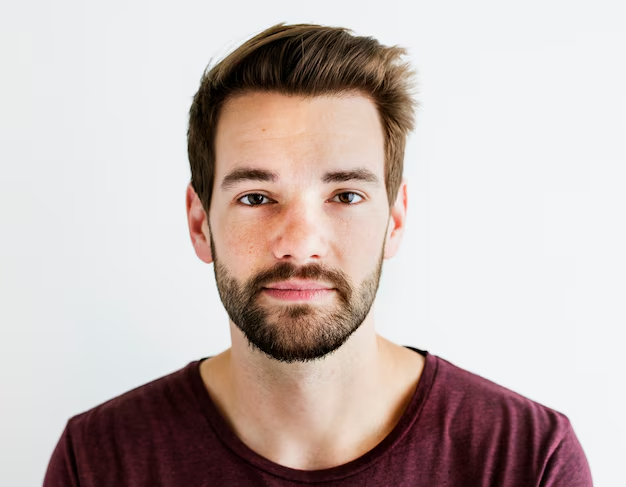

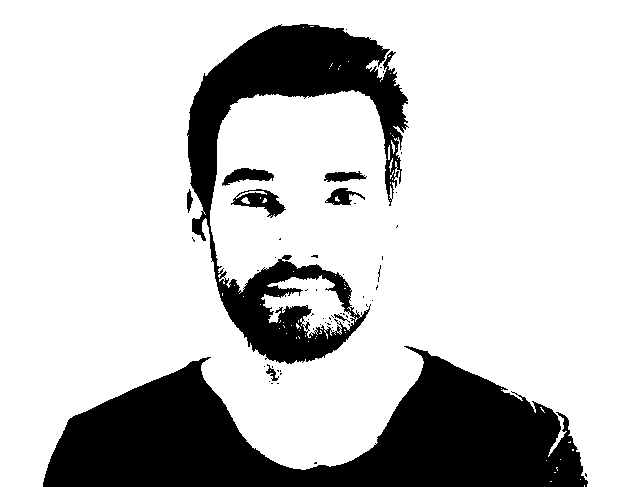

In [ ]:
import cv2

# Read image
img = cv2.imread('sample.avif')

# Convert to grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Apply threshold (segmentation)
_, thresh = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)

# Show output
from google.colab.patches import cv2_imshow

cv2_imshow(img)
cv2_imshow(thresh)

cv2.waitKey(0)
cv2.destroyAllWindows()

##8) Object Recognition

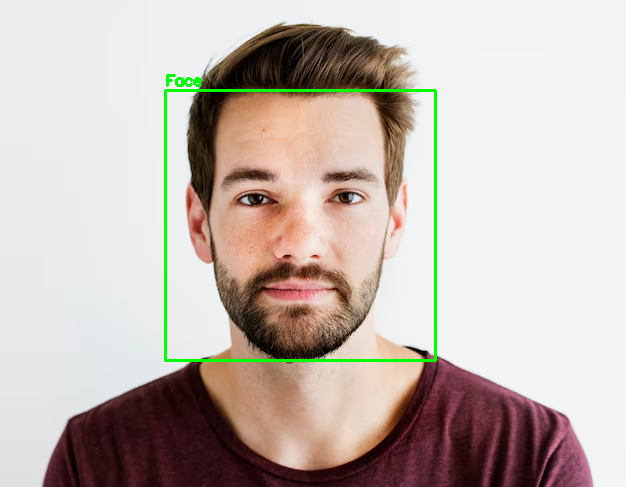

In [ ]:
import cv2

# Load prebuilt face detector
face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
)

# Read image
img = cv2.imread('sample.avif')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Detect faces
faces = face_cascade.detectMultiScale(gray, 1.3, 5)

# Draw boxes
for (x, y, w, h) in faces:
    cv2.rectangle(img, (x, y), (x+w, y+h), (0, 255, 0), 2)
    cv2.putText(img, "Face", (x, y-5),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,255,0), 2)

# Show output
from google.colab.patches import cv2_imshow
cv2_imshow(img)

## 9) Object Labelling

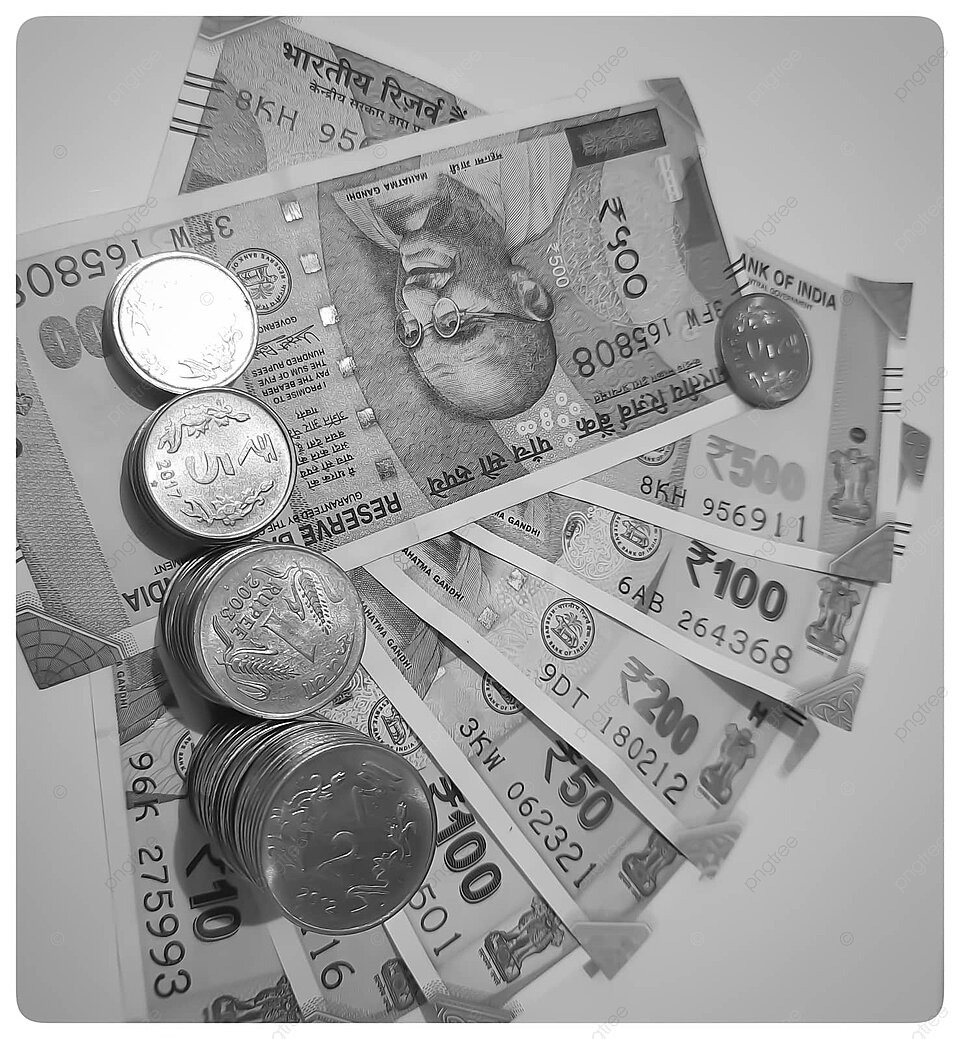

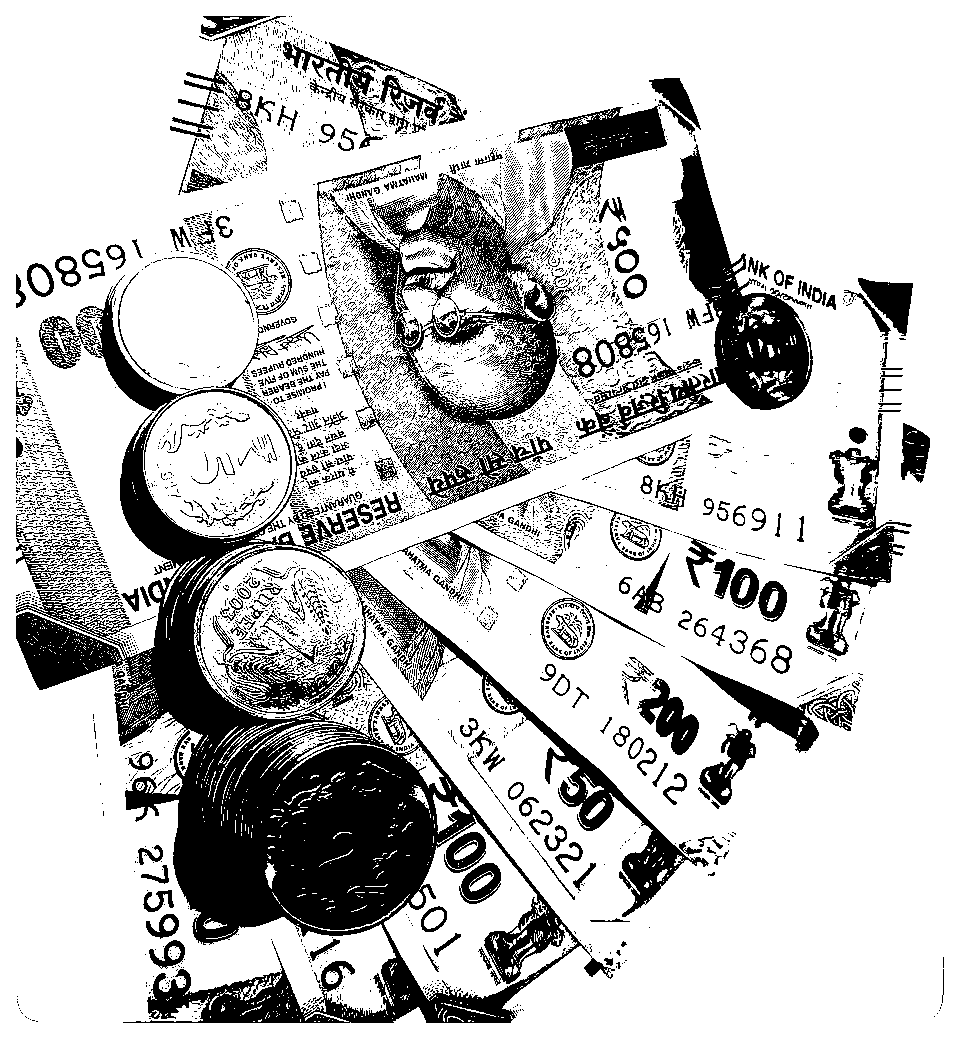

In [ ]:
import cv2

# Read image
img = cv2.imread('objectlabel.jpg', 0)

# Convert to binary
_, thresh = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)

# Label objects
num_labels, labels = cv2.connectedComponents(thresh)

# Convert to color for display
output = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)

# Draw labels
for i in range(1, num_labels):
    mask = (labels == i).astype("uint8") * 255
    x, y, w, h = cv2.boundingRect(mask)

    cv2.rectangle(output, (x,y), (x+w,y+h), (0,255,0), 2)
    cv2.putText(output, f"Obj {i}", (x,y-5),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,255,0), 1)

from google.colab.patches import cv2_imshow

cv2_imshow(img)
cv2_imshow(thresh)